# **YOLO**
## **YOLO - Detección y seguimiento de muñeca mediante distancias**
Pasos a seguir:
1. Detectar una muñeca con YOLO.
2. Realizar el seguimiento de la muñeca seleccionada mediante distancias.

Para llevar a cabo esta tarea, seleccionamos la primera muñeca derecha (`ID=10`) detectada con YOLO. 

Utilizamos la variable `punto_base` para almacenar el punto de partida de cada frame y la variable `history_dist` para almacenar las distancias de las muñecas detectadas durante la reproducción del vídeo. Luego, si no se ha detectado ninguna muñeca aún, se almacena en `punto_base` la primera muñeca detectada. Seguidamente, se guardan las distancias entre los puntos detectados con YOLO y el punto de referencia. 

Una vez recorridos todos los puntos detectados, se ordenan las distancias de dichos puntos y se escoge el mejor resultado: el punto con la menor distancia. Luego, si aún no hay resultados o la máxima distancia es nula, se añade el resultado obtenido. En caso contrario, se comprueba primero que la distancia al punto base del nuevo resultado sea, como mucho, 1.8 veces la máxima distancia encontrada. En el caso de ninguno de los puntos detectados cumpla esta condición, se añade el punto `(0,0)`, indicando que no se ha detectado la muñeca.

In [ ]:
import cv2
import numpy as np
import math
import os
from ultralytics import YOLO


model = YOLO('yolo11x-pose.pt')
video = cv2.VideoCapture("videos/people2.mp4")

success, frame = video.read()
size=(frame.shape[1], frame.shape[0])
fourcc = cv2.VideoWriter_fourcc(*'DIVX')
video_out = cv2.VideoWriter('output/yolo_pose.mp4', fourcc, 30.0, size)

# Variable para guardar el punto base
punto_base = None
# Variable para guardar el historial de las distancias entre los puntos nuevos y el punto de referencia
history_dist = []
# Variable para guardar el historial de puntos detectados
history_points = []

# Crear una imagen de máscara para dibujar
mask = np.zeros_like(frame)
i = 0 # contador

while (success):
    puntos =[]
    dist_ptos = [] # Variable para guardar las distancias de todos los puntos detectados en un frame
   
    results = model.track(frame, verbose=False)[0]

    for r in results:
        kpts = r.keypoints
        keypoint=kpts.xy[0,10] # ID = 10 (muñeca derecha)
        x, y = (int(keypoint[0])),(int(keypoint[1]))
                
    ####
    # Este código es de invención propia
    ####
        # Si aún no hay punto de referencia, coge el primero que detecta YOLO
        if punto_base is None:
            punto_base = keypoint
            cv2.circle(frame, (x,y), 5, (0, 0, 255), -1)
        # Calcula la distancia entre el punto de referencia y el punto detectado
        dist_temp = math.dist(punto_base, keypoint) # función buscada en Google
        # Se guarda la distancia en la lista
        dist_ptos.append((keypoint, dist_temp))
    # Se escoge el punto con menor distancia
    mejor = sorted(dist_ptos, key= lambda x: x[1])[0]

    if len(history_dist) != 0 and sum(history_dist) != 0:
        # Si la distancia es, como mucho, 1.8 veces la mayor distancia 
        # de las distancias del historial, se toma como punto bueno
        if mejor[1] < max(history_dist) * 1.8:
            punto_base = mejor[0]
            history_points.append(punto_base)
            history_dist.append(mejor[1])
            # Dibujamos las trayectorias (código reciclado de Lucas-Kanade)
            if (int(history_points[-2][0]), int(history_points[-2][1])) != (0,0): # dibujar línea solo si se ha detectado un punto anteriormente
                mask = cv2.line(mask, (int(mejor[0][0]), int(mejor[0][1])), (int(history_points[-2][0]), int(history_points[-2][1])), (0, 255, 0), 2)
            frame = cv2.circle(frame, (int(mejor[0][0]), int(mejor[0][1])), 3, (0, 0, 255), -1)

        else:
            # No se detecta, por tanto, ponemos a (0,0)
            history_points.append((0,0))
    else: 
        # Añadir los primeros puntos (len(history_dist) == 0 o sum(history_dist) == 0)
        punto_base = mejor[0]
        history_points.append(punto_base)
        history_dist.append(mejor[1])
        if len(history_points) > 1: # si hay al menos 2 puntos para graficar la línea
            mask = cv2.line(mask, (int(mejor[0][0]), int(mejor[0][1])), (int(history_points[-2][0]), int(history_points[-2][1])), (0, 255, 0), 2)
        cv2.circle(frame, ((int(mejor[0][0])), (int(mejor[0][1]))), 5, (0, 0, 255), -1)
    
    ####
    # Mostrar el fotograma anotado
    img = cv2.add(frame, mask)
    cv2.imshow('YOLO',img)
    video_out.write(img)
    success, frame = video.read()
    key = cv2.waitKey(30) & 0xFF
    if key == 27:
        break
    elif key == ord('s'): # guardar frame si se presiona la tecla 'S' (reciclado del código de Farnebäck)
        os.makedirs("output/yolo", exist_ok=True)
        cv2.imwrite(f"output/yolo/yolo_frame{i}.png", img)
    i += 1
    

# Liberar el objeto de captura de video y cerrar la ventana de visualización
video.release()
video_out.release()
cv2.destroyAllWindows()

Graficamos las coordenadas X e Y con respecto al tiempo (medido en frames):

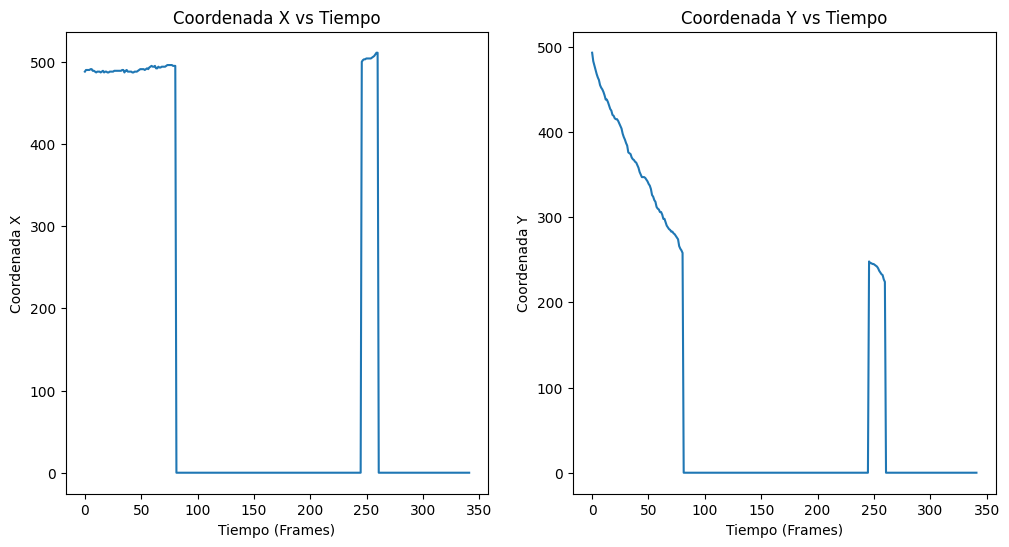

In [11]:
####
# Este código es de invención propia
####

import matplotlib.pyplot as plt
t = np.linspace(0, len(history_points), num=len(history_points))
x_points = []
y_points = []
for point in history_points:
    x_points.append(int(point[0]))
    y_points.append(int(point[1]))

plt.figure(1, (12,6))
plt.subplot(1,2,1)
plt.plot(t, x_points)
plt.ylabel("Coordenada X")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada X vs Tiempo")
plt.subplot(1,2,2)
plt.plot(t, y_points)
plt.ylabel("Coordenada Y")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada Y vs Tiempo")
plt.show()
    

En las gráficas se observa que en un principio la detección de la muñeca se realiza correctamente. También se puede observar en el vídeo:
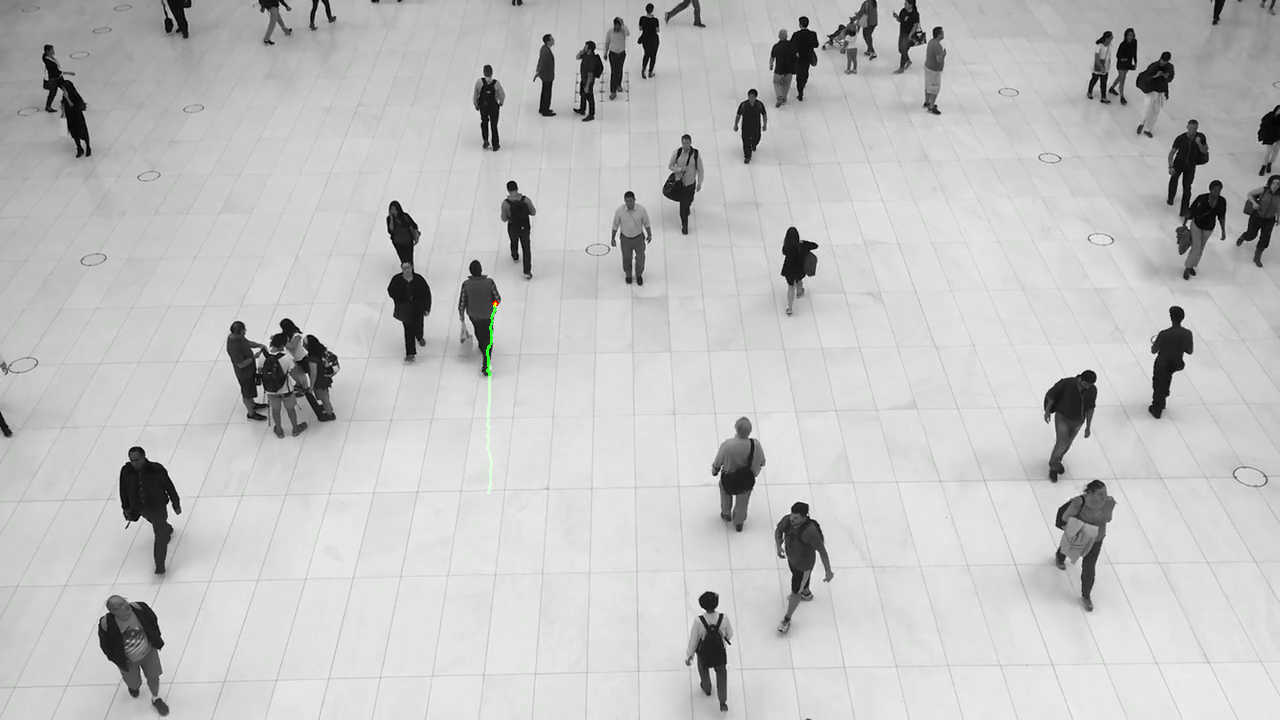

Luego, hay varios frames en los que no detecta la muñeca. Esto ocurre porque o en un frame no se detecta la muñeca o no cumple la condición de que, como mucho, la distancia entre el nuevo punto y el de referencia sea 1.8 veces la máxima distancia detectada. Al no detectar un frame, las probabilidades de que la siguiente detección cumpla la condición es menor. Se puede ver en la siguiente imagen que la detección de la muñeca falló en un punto y no se volvió a cumplir la condición para que se detectase de nuevo:
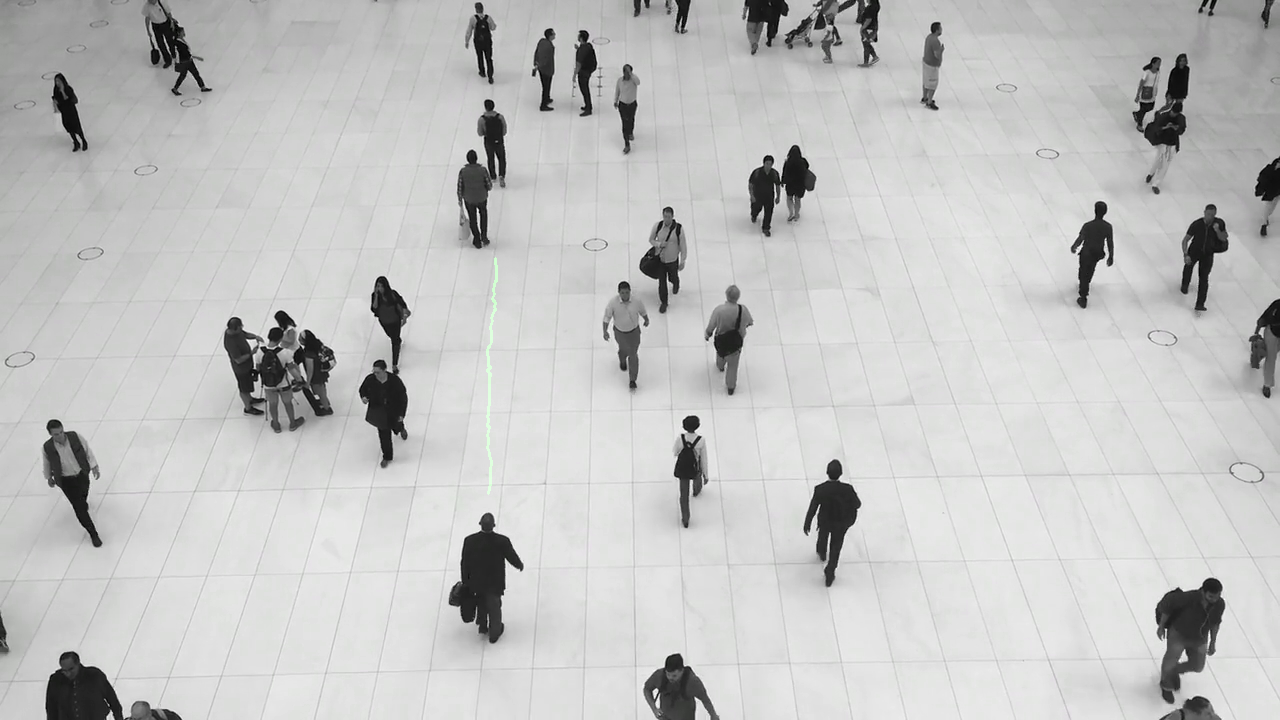

Finalmente, en las gráficas observamos que tras varios frames sin detección, se vuelve a detectar una muñeca. En el vídeo vemos que una persona distinta pasa por el mismo sitio donde se quedó la última detección de la muñeca. Por lo tanto, se trataría de un error del algoritmo diseñado.
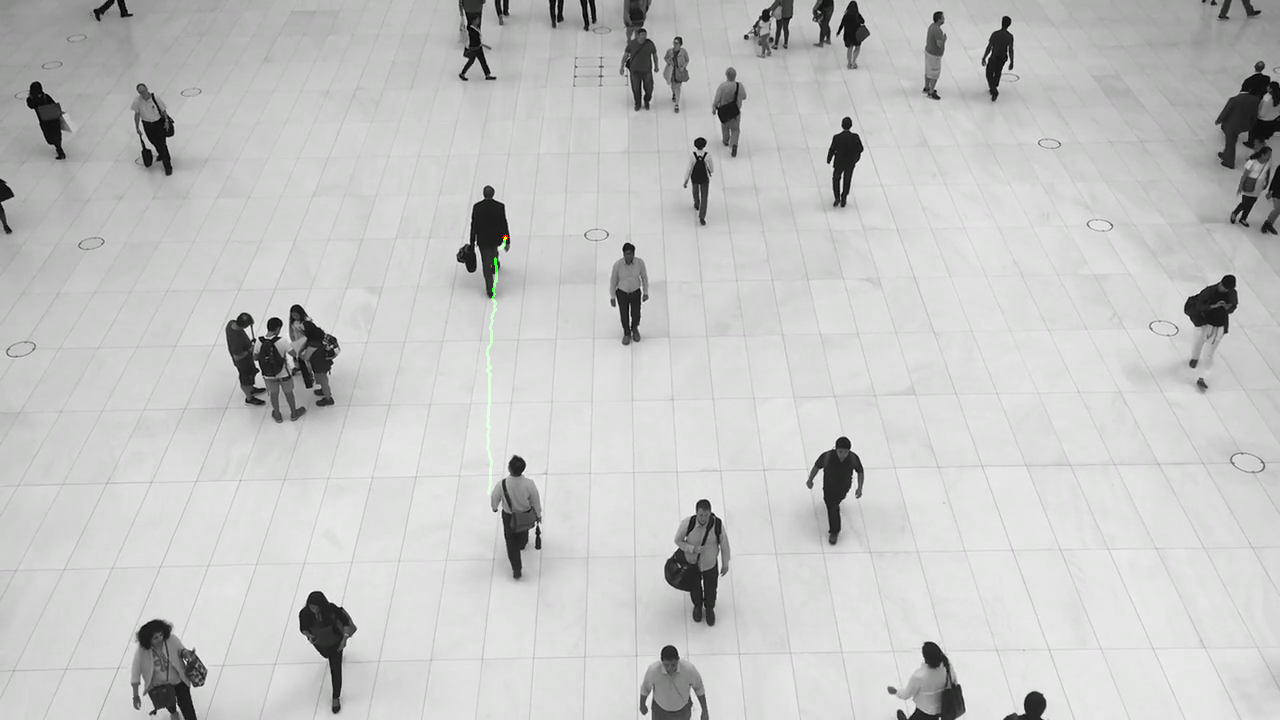


## **YOLO + Lucas-Kanade - Detección y seguimiento de muñeca**
Pasos a seguir:
1. Detectar una muñeca con YOLO.
2. Realizar el seguimiento de la muñeca seleccionada con Lucas-Kanade.

Para llevar a cabo esta tarea, seleccionamos la primera muñeca derecha (`ID=10`) detectada con YOLO. 

Utilizamos la variable `p0` para almacenar las coordenadas del primer frame de la muñeca a detectar y la variable `history_points` para almacenar los puntos para luego graficarlos. 

Una vez detectada la muñeca, seguimos el punto con la implementación de Lucas-Kanade de OpenCV.

In [ ]:
import cv2
import numpy as np
import os
from ultralytics import YOLO

VIDEO_PATH = "videos/people2.mp4"

video = cv2.VideoCapture(VIDEO_PATH)

# Model
model = YOLO('yolo11x-pose.pt')

# Parámetros para detectar esquinas (ShiTomasi)
feature_params = dict(
    maxCorners=500,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)
# Parámetros de Lucas-Kanade
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)
# Primer frame
ret, old_frame = video.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

p0 = None
# Variable para guardar el historial de puntos detectados
history_points = []

results = model.track(old_frame, verbose=False)[0]
for r in results:
    if p0 is None:
        kpts = r.keypoints
        keypoint=kpts.xy[0,10] # ID = 10 (muñeca derecha)
        x, y = (int(keypoint[0])),(int(keypoint[1]))
        p0 = np.array((x, y)).reshape(-1, 1, 2) # Dimensiones para la función cv2.calcOpticalFlowPyrLK (se obtuvo del código de OpenCV)
        p0 = np.float32(p0) # Corrección de Gemini para solventar problema de tipo de datos en cv2.calcOpticalFlowPyrLK
        history_points.append(p0)
        break

# Crear una imagen de máscara para dibujar
mask = np.zeros_like(old_frame)
i = 0 # contador
while True:
    ret, frame = video.read()
    if not ret:
        break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Calculamos flujo óptico (Lucas-Kanade)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    if p1 is None:
        break
    # seleccionamos puntos válidos
    good_new = p1[st == 1]
    good_old = p0[st == 1]
    history_points.append(good_new)
    # Dibujamos las trayectorias
    for (new, old) in zip(good_new, good_old):
        x_new, y_new = new.ravel()
        x_old, y_old = old.ravel()
        mask = cv2.line(mask, (int(x_new), int(y_new)), (int(x_old), int(y_old)), (0, 255, 0), 2)
        frame = cv2.circle(frame, (int(x_new), int(y_new)), 3, (0, 0, 255), -1)
    img = cv2.add(frame, mask)
    cv2.imshow("YOLO + Lucas-Kanade", img)
    key = cv2.waitKey(30) & 0xFF
    if key == 27:
        break
    elif key == ord('s'): # guardar frame si se presiona la tecla 'S' (reciclado del código de Farnebäck)
        os.makedirs("output/yolo", exist_ok=True)
        cv2.imwrite(f"output/yolo/yolo_lk_frame{i}.png", img)
    # Actualizamos
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)
    i += 1

cv2.destroyAllWindows()

Usamos Gemini para resolver el siguiente problema:
```bash
---------------------------------------------------------------------------
error                                     Traceback (most recent call last)
Cell In[22], line 52
     50 frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
     51 # Calculamos flujo óptico (Lucas-Kanade)
---> 52 p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
     53 if p1 is None:
     54     break

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1281: error: (-215:Assertion failed) (npoints = prevPtsMat.checkVector(2, CV_32F, true)) >= 0 in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'
```

A continuación, graficamos las coordenadas X e Y con respecto al tiempo:

341


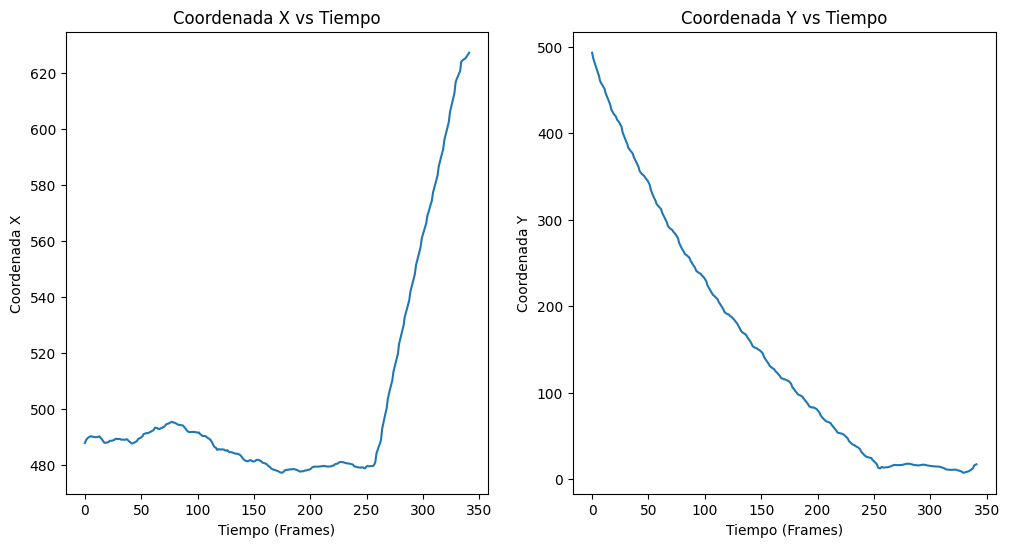

In [8]:
####
# Este código es de invención propia
####

import matplotlib.pyplot as plt
t = np.linspace(0, len(history_points), num=len(history_points))
x_points = []
y_points = []
for point in history_points:
    x_points.append(point.reshape(-1)[0])
    y_points.append(point.reshape(-1)[1])

print(len(history_points))
plt.figure(1, (12,6))
plt.subplot(1,2,1)
plt.plot(t, x_points)
plt.ylabel("Coordenada X")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada X vs Tiempo")
plt.subplot(1,2,2)
plt.plot(t, y_points)
plt.ylabel("Coordenada Y")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada Y vs Tiempo")
plt.show()
    

Atentiendo a las gráficas obtenidas, concluimos que al realizar el seguimiento de la muñeca con Lucas-Kanade se obtienen mejores resultados, pues el seguimiento se realiza correctamente hasta que la persona sale de la imagen. La siguiente imagen muestra el correcto seguimiento:

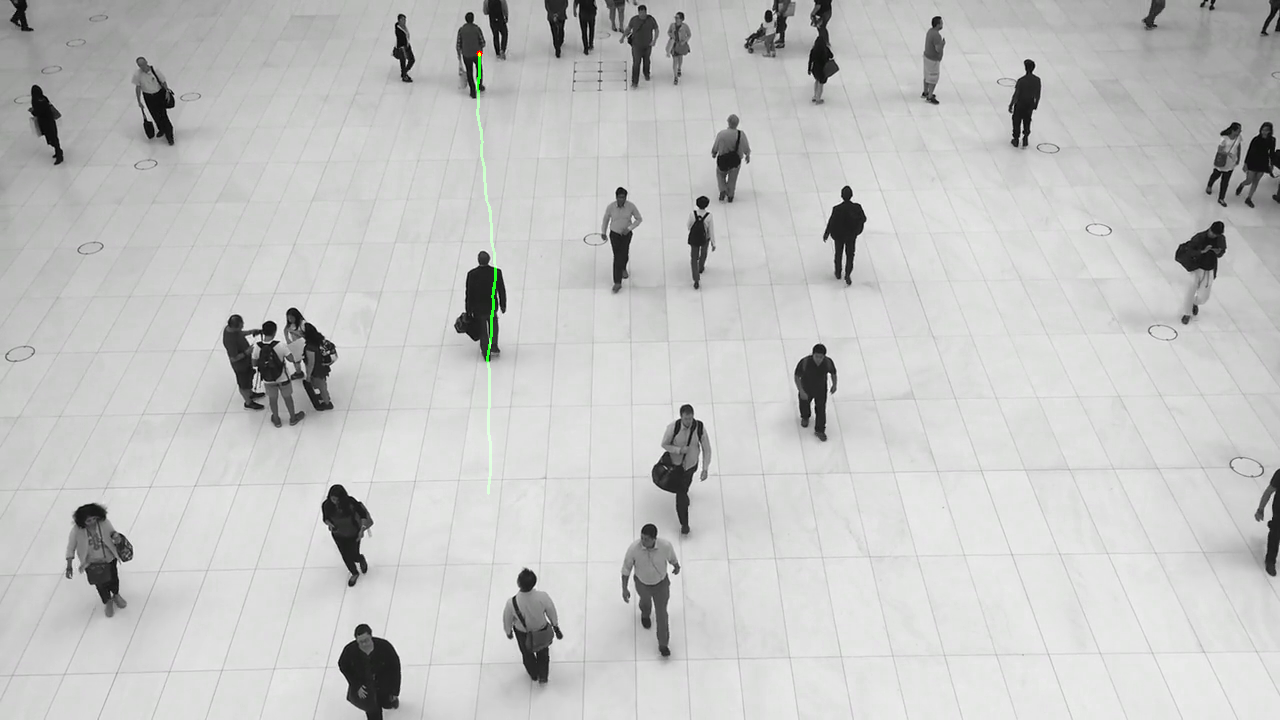

No obtante, cuando la persona ya no está en la imagen, Lucas-Kanade sigue otro punto que se cruza y, por eso, pasados los 250 frames, la coordenada X aumenta drásticamente. Esto se puede observar en la siguiente imagen:

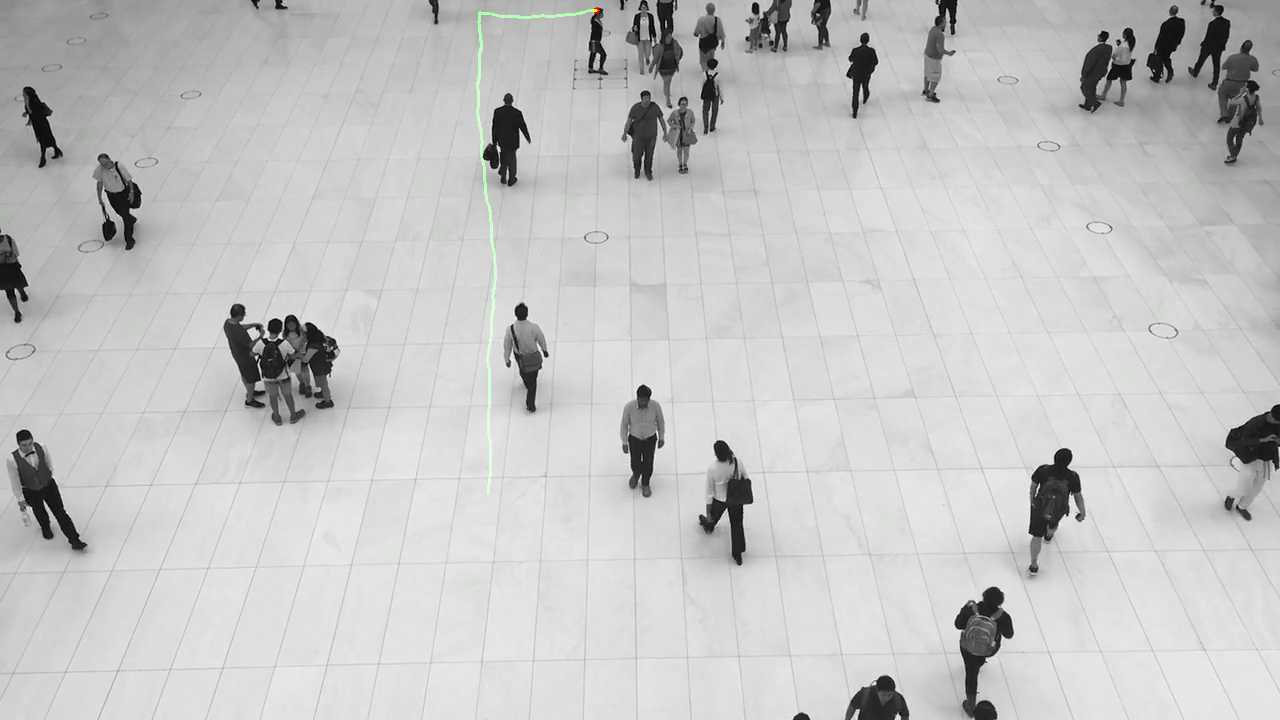